#------------------------------------------
Part 4 - Data Visualization & Machine Learning

THEME:- Student Performance Analysis & Prediction
#------------------------------------------




In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [8]:
#LOAD THE DATASET
csv_content = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

with open('student.csv', 'w') as file:
    file.write(csv_content)


In [9]:
df = pd.read_csv('student.csv')
print(df)

       name  math  science  english  history  pe  attendance_pct  \
0     Alice    88       92       76       80  95              92   
1       Bob    42       55       48       50  60              65   
2   Charlie    75       70       80       68  88              85   
3     Diana    95       98       91       89  97              98   
4       Eve    38       42       50       45  55              58   
5     Frank    60       65       72       58  70              78   
6     Grace    55       48       44       52  62              60   
7     Henry    82       79       85       77  90              88   
8      Iris    70       74       68       65  78              80   
9      Jack    30       35       40       28  45              50   
10    Karen    65       60       70       62  75              72   
11     Liam    48       52       44       55  58              62   
12      Mia    91       94       88       92  96              95   
13     Noah    58       62       55       60  68

In [10]:
subject_columns = ['math', 'science', 'english', 'history', 'pe']

#TASK 1 DATA EXPLORATION WITH PANDAS

In [11]:
print("-" * 55)
print("Task 1: Data Exploration with Pandas")
print("-" * 55)

#Now I will be printing first 5 rows
print("\n[First 5 rows]")
print(df.head().to_string(index = False))

#Shape and column types
print(f"\n[Shape] {df.shape[0]} rows x{df.shape[1]} columns")
print("\n[Data types per column]")
print(df.dtypes)

#Summary Statistics
#Here we will use describe() which cevers mean,std,min,max,quartile
print("\n[Summary statistics(numeric columns)]\n")
print(df.describe().round(2))


#Pass/Fail Counts
print("\n[Pass/Fail counts]")
print(df['passed'].value_counts().rename({1:'Pass',0:'Fail'}))


#Average subject scores split by Pass/Fail
# I am doing it explicitly way by seperating two mean call and not using groupby
pass_avg = df[df['passed'] == 1][subject_columns].mean()
fail_avg = df[df['passed'] == 0][subject_columns].mean()

print("\n[Average subject scores split by Pass/Fail]")

for subj,val in pass_avg.items():
    print(f" {subj}: {val:.2f}")

#Student with the highest overall average
#mean(axis=1) computes row-wise average across the 5 subject columns
df['_temp_avg'] = df[subject_columns].mean(axis=1)

top_idx = df['_temp_avg'].idxmax()
top_student = df.loc[top_idx,'name']
top_average = df.loc[top_idx,'_temp_avg']

print(f"\n[Top student overall {top_student} - average:{top_average : .2f}]")


#Dropping the temporary column so that it doesn't interfere with anything later
df.drop(columns=['_temp_avg'],inplace=True)




-------------------------------------------------------
Task 1: Data Exploration with Pandas
-------------------------------------------------------

[First 5 rows]
   name  math  science  english  history  pe  attendance_pct  study_hours_per_day  passed
  Alice    88       92       76       80  95              92                  4.5       1
    Bob    42       55       48       50  60              65                  1.2       0
Charlie    75       70       80       68  88              85                  3.0       1
  Diana    95       98       91       89  97              98                  6.0       1
    Eve    38       42       50       45  55              58                  0.8       0

[Shape] 15 rows x9 columns

[Data types per column]
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    fl

#TASK 2 MATPLOTLIB VISUALISATIONS




-------------------------------------------------------
 TASK 2 : MATPLOTLIB VISUALISATIONS
-------------------------------------------------------


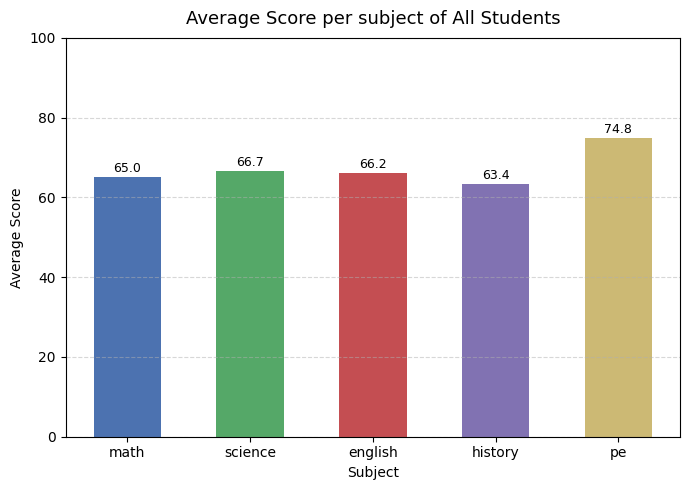

In [16]:
#Adding avg_score column before plotting used in the scatter plot
df['avg_score'] = df[subject_columns].mean(axis=1)

print("\n\n" + "-" * 55)
print(" TASK 2 : MATPLOTLIB VISUALISATIONS")
print("-" * 55)

# Plot 1: Bar Chart for average score per subject
fig,ax = plt.subplots(figsize=(7,5))

subject_means = df[subject_columns].mean()
bar_colors =['#4C72B0','#55A868','#C44E52','#8172B2', '#CCB974']
bars=ax.bar(subject_means.index,subject_means.values,color=bar_colors,width=0.55)

#Now we will be annotating each bar with it's value as I like being explicit about my numbers
for bar in bars:
    ax.text(bar.get_x()+ bar.get_width()/2,bar.get_height()+0.5,
            f"{bar.get_height():.1f}",ha ='center', va ='bottom', fontsize = 9)

ax.set_title("Average Score per subject of All Students", fontsize = 13,pad =10)
ax.set_xlabel("Subject")
ax.set_ylabel("Average Score")
ax.set_ylim(0,100)
ax.grid(axis = 'y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



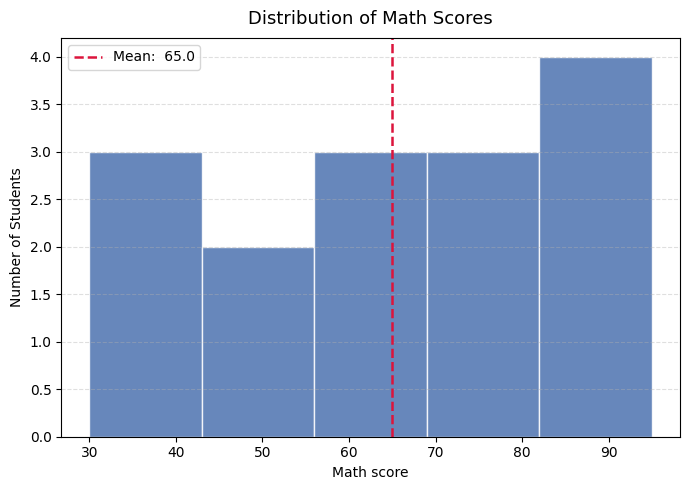

In [27]:
#Plot 2 Histogram for math score distribution

fig,ax = plt.subplots(figsize = (7,5))

ax.hist(df['math'],bins=5,color = '#4C72B0',edgecolor='white',alpha = 0.85)
math_mean = df['math'].mean()

ax.axvline(math_mean,color='crimson',linestyle='--',linewidth=1.8,label = f"Mean: {math_mean: .1f}" )

ax.set_title("Distribution of Math Scores",fontsize =13, pad=10)
ax.set_xlabel("Math score")
ax.set_ylabel("Number of Students")

ax.legend()

ax.grid(axis ='y',linestyle = '--', alpha=0.4)

plt.tight_layout()
plt.show()






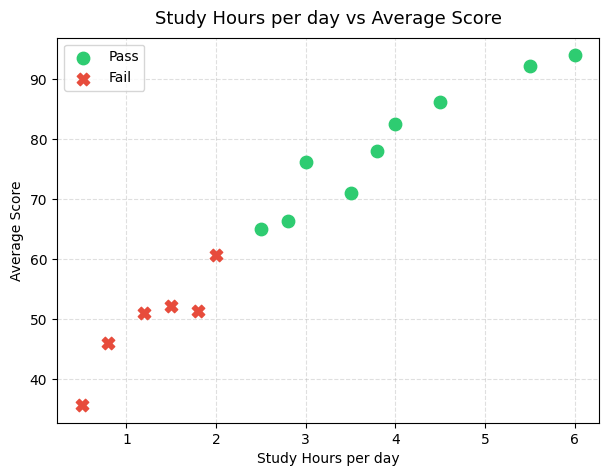

In [31]:
#Plot 3: Scatter plot for study hours vs avg_score,coloured by pass/fail
fig,ax =plt.subplots(figsize=(7,5))

pass_df  = df[df['passed']==1]
fail_df = df[df['passed']== 0]

#Plotting each group seperately so the legend works cleanly
ax.scatter(pass_df['study_hours_per_day'],pass_df['avg_score'],
          color = '#2ecc71', marker = 'o', s=80, label='Pass', zorder= 3)

ax.scatter(fail_df['study_hours_per_day'],fail_df['avg_score'],
          color = '#e74c3c', marker = 'X', s=80, label='Fail', zorder= 3)

ax.set_title("Study Hours per day vs Average Score", fontsize = 13, pad = 10)
ax.set_xlabel("Study Hours per day")
ax.set_ylabel("Average Score")
ax.legend()
ax.grid(linestyle='--',alpha=0.4)
plt.tight_layout
plt.show()

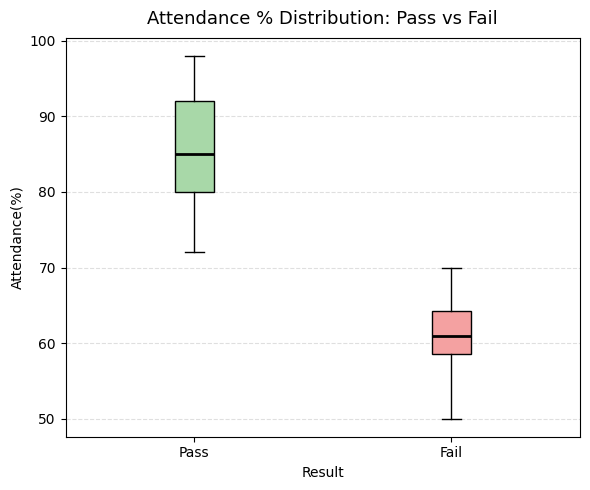

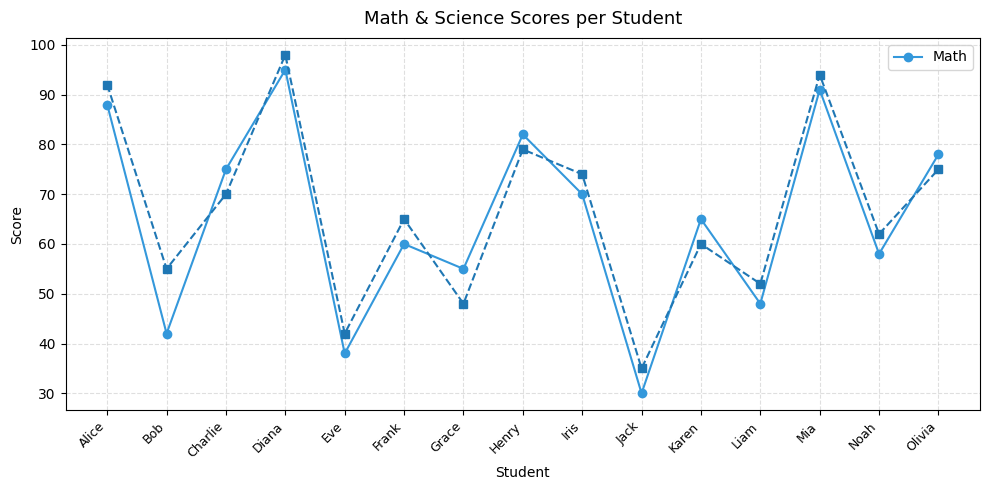

In [49]:
# Plot 4 : Box Plot for attendance_pct by pass/fail
fig,ax = plt.subplots(figsize = (6,5))

pass_att = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_att = df[df['passed'] == 0]['attendance_pct'].tolist()

bp = ax.boxplot([pass_att,fail_att],
               tick_labels =['Pass','Fail'],
               patch_artist = True,
               medianprops=dict(color='black',linewidth=2))

#Colour the two boxes differently
bp['boxes'][0].set_facecolor('#a8d8a8') #soft green for Pass
bp['boxes'][1].set_facecolor('#f4a1a1') #soft red for Fail

ax.set_title("Attendance % Distribution: Pass vs Fail",fontsize =13, pad=10 )

ax.set_xlabel("Result")
ax.set_ylabel("Attendance(%)")

ax.grid(axis='y',linestyle='--',alpha = 0.4)

plt.tight_layout()
plt.show()




#Plit 5 Line Plot for Math & Science scores per student
fig,ax = plt.subplots(figsize=(10,5))
x_positions = range(len(df))

ax.plot(x_positions,df['math'], marker = 'o', linestyle = '-',
       color = '#3498db', label = 'Math')

ax.plot(x_positions,df['science'], marker='s', linestyle='--',)
ax.set_xticks(list(x_positions))
ax.set_xticklabels(df['name'], rotation=45,ha='right',fontsize=9)
ax.set_title("Math & Science Scores per Student",  fontsize=13,pad=10)

ax.set_xlabel("Student")
ax.set_ylabel("Score")
ax.legend()
ax.grid(linestyle='--',alpha=0.4)
plt.tight_layout()
plt.show()

-------------------------------------------------------
Task 3: SEABORN VISUALISATIONS
-------------------------------------------------------


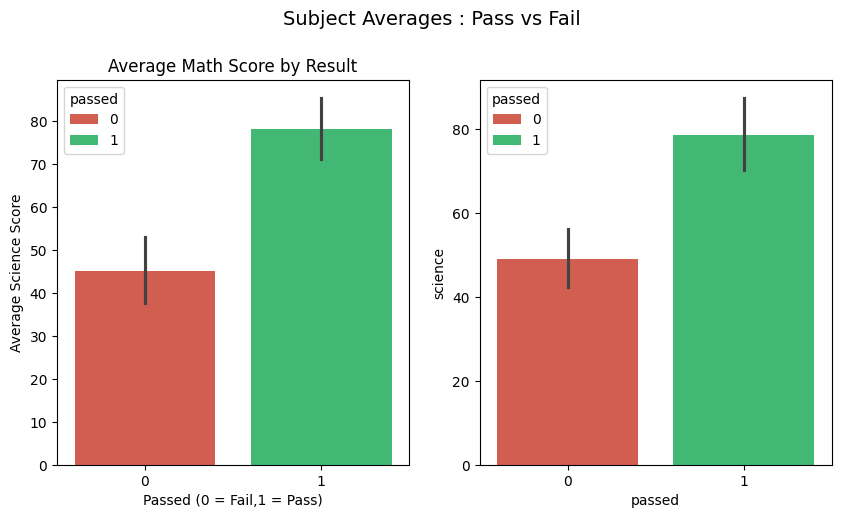

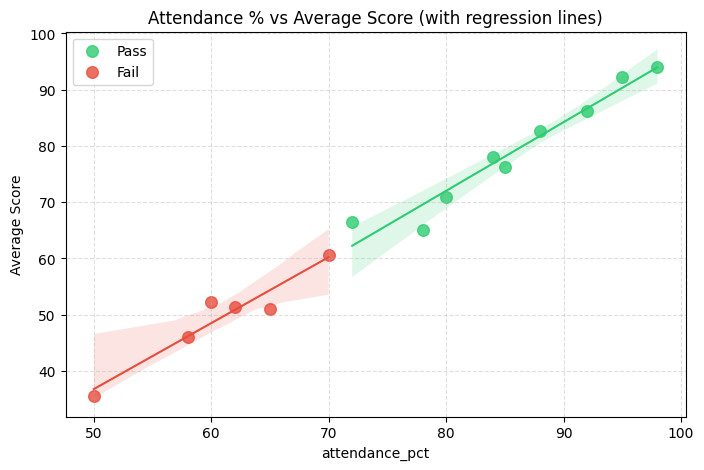

In [53]:
# TASK 3 SEABORN VISUALIZATIONS
print("-" * 55)
print("Task 3: SEABORN VISUALISATIONS")
print("-" * 55)

#Plot 6 : Seaborn bar for average math and science by pass/fail
fig,(ax1,ax2)= plt.subplots(1,2,figsize=(10,5),sharey=False)

sns.barplot(data=df, x='passed',y='math', ax=ax1,hue ='passed',palette = ['#e74c3c','#2ecc71'])
sns.barplot(data=df, x='passed', y='science', ax=ax2,hue='passed', palette = ['#e74c3c','#2ecc71'])

ax1.set_title("Average Math Score by Result")
ax1.set_xlabel("Passed (0 = Fail,1 = Pass)")
ax1.set_ylabel("Average Science Score")

fig.suptitle("Subject Averages : Pass vs Fail", fontsize = 14, y =1.02)
plt.show()

#Plot 7 : Seaborn scatter + regression attendance vs avg_score
fig,ax = plt.subplots(figsize=(8,5))

#regplot draws scatter and regression line in once
#Here I will plot each group seperately so they get different colours + labels
sns.regplot(data=df[df['passed']==1],
           x = 'attendance_pct',y='avg_score',
           ax=ax,color='#2ecc71', label='Pass',scatter_kws={'s':70}, line_kws={'linewidth':1.5})

sns.regplot(data=df[df['passed']==0], x='attendance_pct',y='avg_score', ax=ax,color='#e74c3c',label='Fail',
           scatter_kws={'s':70}, line_kws={'linewidth':1.5})
ax.set_title("Attendance % vs Average Score (with regression lines)", fontsize =12)
ax.set_ylabel("Average Score")
ax.legend()
ax.grid(linestyle ='--',alpha=0.4)
plt.tight_layout
plt.show()

In [ ]:
#Seaborn vs Matplotlib comparision:
#Seaborn felt noticeably easier for grouped plot - sns.barplot handles

#the split by category automatically,whereas in matplotlib I had to

#manually seperate  data into two groups and call plot() twice.

# The regplot in particular saved alot of work; doing the same regression.

#overlay in raw matplotlib would need numpy's polyfit and extra lines.

#That said,matplotlib gave me finer control over things like bar width,

#exact colours per bar,and custom annotation,seaborn's abstraction
#sometimes hides options I wanted to tweak.

In [70]:
#TASK 4 - MACHINE LEARNING WITH SCIKIT-LEARN
print("\n\n" + "="* 55)
print(" TASK 4 : MACHINE LEARNING")
print("=" * 55)

#Step 1:Prepare Data
#Features everything except name and the target column
feature_columns = ['math','science','english','history','pe','attendance_pct', 'study_hours_per_day']

X = df[feature_columns] #here df stays intact;name column never touched
y = df['passed']

#80/20 split - random_state=42 keeps results reproducible
X_train,X_test, y_train , y_test = train_test_split( X,y,test_size=0.2,random_state=42)

# Scaling Features

#I will approach this by trying to fit only  on training data,and then apply to both as fitting on test data 
#would cause data leakage issue i.e If I try to fit the entire dataset including the test data,
#the scaler learns the scale of test data too and it can give me falsely accurate or incorrect results.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n  Training Samples : {len(X_train)}")
print(f" Test Samples:  {len(X_test)}")



 TASK 4 : MACHINE LEARNING

  Training Samples : 12
 Test Samples:  3


In [71]:
#Step 2 : Training a Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=200)
model.fit(X_train_scaled,y_train)


train_accuracy = model.score(X_train_scaled,y_train)
print(f"  Training accuracy : {train_accuracy *100:.1f}%")

  Training accuracy : 100.0%


In [73]:
#Step 3 : Evaluating on testing dataset
y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test,y_pred)

print(f" Test accuracy  : {test_accuracy* 100:.1f}%")

 Test accuracy  : 100.0%
